In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast  # For literal_eval to parse strings that look like lists

# Load data
df = pd.read_csv('Cleaned_dataset.csv')

# Inspection
print(df.info()) # Check for missing values
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8980 entries, 0 to 8979
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pbp_id              8980 non-null   int64 
 1   date                8980 non-null   object
 2   server1             8980 non-null   object
 3   server2             8980 non-null   object
 4   winner              8980 non-null   int64 
 5   pbp                 8980 non-null   object
 6   score               8980 non-null   object
 7   wh_minutes          8980 non-null   int64 
 8   score_winner_valid  8980 non-null   bool  
 9   pbp_fixed           8980 non-null   object
 10  pbp_set_count       8980 non-null   int64 
 11  score_set_count     8980 non-null   int64 
 12  set_count_match     8980 non-null   bool  
 13  pbp_set_winners     8980 non-null   object
 14  set_match           8980 non-null   bool  
 15  pbp_match_winner    8980 non-null   int64 
 16  winner_match        8980

### Removed the rows having the total macth time less than 30 min. and greater than 500 min.

In [3]:
# 1. Fix duration errors
df_clean = df[(df['wh_minutes'] > 30) & (df['wh_minutes'] < 500)].copy()

# 2. Fix date formats
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')

# 3. Drop rows with missing critical info
df_clean = df_clean.dropna(subset=['date', 'pbp_set_winners'])

### Compared weather the 1st set winner actually won the match or not, and mark it as 'comeback'

In [4]:
# 1. Extract the winner of the first set
def get_first_set_winner(val):
    try:
        # Convert string "[1, 2]" to an actual list [1, 2]
        winners = ast.literal_eval(val)
        return winners[0]
    except:
        return None

df_clean['first_set_winner'] = df_clean['pbp_set_winners'].apply(get_first_set_winner)

# 2. Determine if the first set winner won the match
df_clean['first_set_winner_won_match'] = df_clean['first_set_winner'] == df_clean['winner']

# 3. Mark comebacks
df_clean['is_comeback'] = (df_clean['first_set_winner'] != df_clean['winner'])

# 4. Calculate Intensity (Total points played)
df_clean['total_points'] = (
    df_clean['pbp']
    .str.replace('A', 'S', regex=False)
    .str.replace('D', 'R', regex=False)
    .str.replace(';', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace('/', '', regex=False)
    .str.len()
)


In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8980 entries, 0 to 8979
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   pbp_id                      8980 non-null   int64         
 1   date                        8980 non-null   datetime64[ns]
 2   server1                     8980 non-null   object        
 3   server2                     8980 non-null   object        
 4   winner                      8980 non-null   int64         
 5   pbp                         8980 non-null   object        
 6   score                       8980 non-null   object        
 7   wh_minutes                  8980 non-null   int64         
 8   score_winner_valid          8980 non-null   bool          
 9   pbp_fixed                   8980 non-null   object        
 10  pbp_set_count               8980 non-null   int64         
 11  score_set_count             8980 non-null   int64       

In [6]:
# Hypothesis 1: Does winning the first set guarantee a win?
prob_win_after_set1 = df_clean['first_set_winner_won_match'].mean()
print(f"Probability of winning match after 1st set: {prob_win_after_set1:.2%}")

# Hypothesis 2: How much longer is a 3-set match?
avg_time = df_clean.groupby('pbp_set_count')['wh_minutes'].mean()
print(avg_time)

Probability of winning match after 1st set: 83.92%
pbp_set_count
2     79.273311
3    124.473384
Name: wh_minutes, dtype: float64


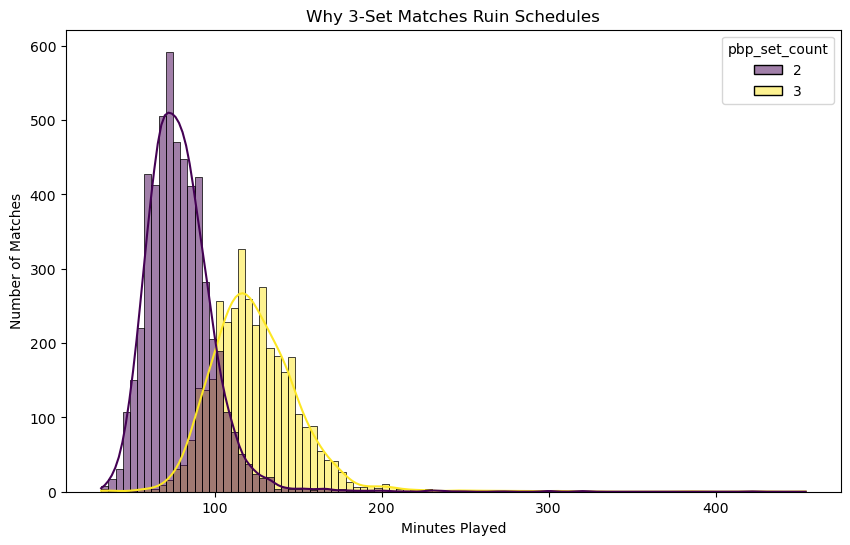

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='wh_minutes', hue='pbp_set_count', kde=True, palette='viridis')
plt.title('Why 3-Set Matches Ruin Schedules')
plt.xlabel('Minutes Played')
plt.ylabel('Number of Matches')
plt.show()

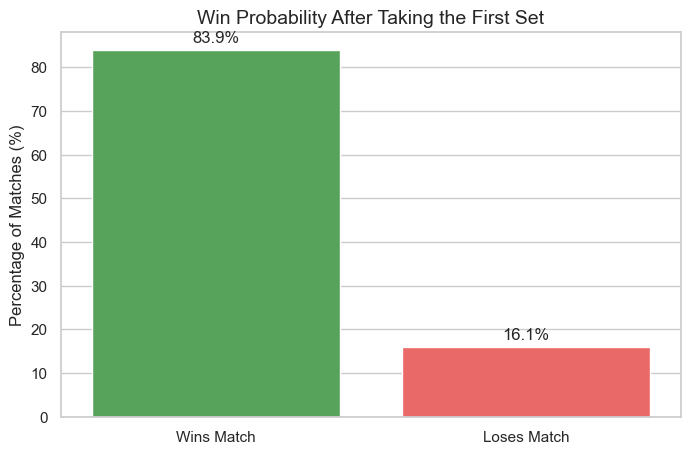

In [8]:
# Set global style
sns.set_theme(style="whitegrid")

# Visual 1: Win Probabilities
plt.figure(figsize=(8, 5))
data = df_clean['first_set_winner_won_match'].value_counts(normalize=True) * 100
ax = sns.barplot(x=['Wins Match', 'Loses Match'], y=data.values, palette=['#4CAF50', '#FF5252'])
plt.title('Win Probability After Taking the First Set', fontsize=14)
plt.ylabel('Percentage of Matches (%)')

# ➕ Add percentage labels
for i, v in enumerate(data.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom')

plt.savefig('visual1_first_set_advantage.png')
plt.show()


# # Visual 2: Duration Distribution
# plt.figure(figsize=(10, 6))
# sns.kdeplot(data=df_clean[df_clean['pbp_set_count']==2]['wh_minutes'], label='2-Set Match', fill=True)
# sns.kdeplot(data=df_clean[df_clean['pbp_set_count']==3]['wh_minutes'], label='3-Set Match', fill=True)
# plt.title('How the 3rd Set Impacts Tournament Scheduling')
# plt.xlabel('Minutes Played')
# plt.legend()
# plt.savefig('visual2_duration_dist.png')

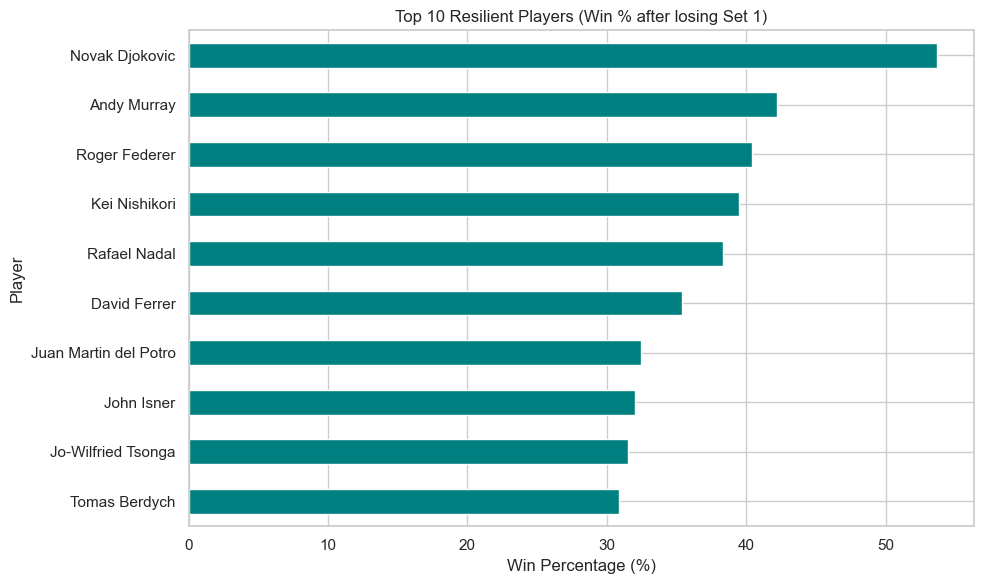

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# We need to see every time a player LOST set 1 and then check if they WON the match
def calculate_resilience(player_name):
    # Filter matches where the player was either server1 or server2
    matches = df_clean[(df_clean['server1'] == player_name) | (df_clean['server2'] == player_name)]
    
    # Matches where player lost set 1
    # first_set_winner == 2 means server 2 won set 1, first_set_winner == 1 means server 1 won set 1
    lost_s1 = matches[((matches['server1'] == player_name) & (matches['first_set_winner'] == 2)) | 
                      ((matches['server2'] == player_name) & (matches['first_set_winner'] == 1))]
    
    if len(lost_s1) < 20: 
        return None # Sample size filter
    
    # Of those, how many did they win the match?
    wins = lost_s1[((lost_s1['server1'] == player_name) & (lost_s1['winner'] == 1)) | 
                   ((lost_s1['server2'] == player_name) & (lost_s1['winner'] == 2))]
    
    return (len(wins) / len(lost_s1)) * 100

# Apply this to top players (most active)
top_players = pd.concat([df_clean['server1'], df_clean['server2']]).value_counts().head(50).index
resilience_scores = {p: calculate_resilience(p) for p in top_players if calculate_resilience(p) is not None}

# Sort and Plot
# To have the highest value at the top of a horizontal bar chart, 
# we sort ascending so the largest values are at the end of the Series.
res_df = pd.Series(resilience_scores).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
res_df.plot(kind='barh', color='teal', ax=ax)

ax.set_title('Top 10 Resilient Players (Win % after losing Set 1)')
ax.set_xlabel('Win Percentage (%)')
ax.set_ylabel('Player')

plt.tight_layout()
plt.savefig('visual4_resilience.png')

In [10]:
df_clean.sample(20)

,pbp_id,date,server1,server2,winner,pbp,score,wh_minutes,score_winner_valid,pbp_fixed,...,set_count_match,pbp_set_winners,set_match,pbp_match_winner,winner_match,score_set_winners,first_set_winner,first_set_winner_won_match,is_comeback,total_points
3454,4416282,2013-05-08,Tommy Haas,Tommy Robredo,1,SSSS;RSRSSRRSRR;RRSRSR;SSSS;RSRSSRSRRSSS;RSSSS...,6-3 7-5,100,True,SSSS;RSRSSRRSRR;RRSRSR;SSSS;RSRSSRSRRSSS;RSSSS...,...,True,"[1, 1]",False,1,True,"[1, 1]",1,True,False,152
44,2243087,2011-07-31,Alex Kuznetsov,Tim Smyczek,2,SSSRS;SSSS;RSSRRSSS;RSSSRS;RSRRSR;SSSRRS;RSSSS...,6-3 6-3,75,False,SSSRS;SSSS;RSSRRSSS;RSSSRS;RSRRSR;SSSRRS;RSSSS...,...,True,"[2, 2]",False,2,True,"[1, 1]",2,True,False,105
2214,3606015,2012-10-18,Flavio Cipolla,Thomaz Bellucci,2,SSSRRRSS;SRSSRS;RRRSSSRSRSSRSRRSRR;SRRRSSSS;SS...,6-4 6-1,85,False,SSSRRRSS;SRSSRS;RRRSSSRSRSSRSRRSRR;SRRRSSSS;SS...,...,True,"[2, 2]",False,2,True,"[1, 1]",2,True,False,124
1584,3221325,2012-07-14,Harri Heliovaara,Federico Delbonis,2,SRRSRSRR;SSSS;SSSRRS;SARSS;SSRSS;SDRSSS;SRSARR...,6-4 6-2,82,False,SRRSRSRR;SSSS;SSSRRS;SARSS;SSRSS;SDRSSS;SRSARR...,...,True,"[2, 2]",False,2,True,"[1, 1]",2,True,False,118
3929,4738616,2013-07-24,Stanislas Wawrinka,Daniel Gimeno-Traver,1,SRSSS;SSAS;SSDSRS;SSSRS;SSAS;RRSSRSRASS;SSRSS;...,7-5 7-6(4),93,True,SRSSS;SSAS;SSDSRS;SSSRS;SSAS;RRSSRSRASS;SSRSS;...,...,True,"[1, 1]",False,1,True,"[1, 1]",1,True,False,169
5564,6003690,2014-05-12,Alejandro Gonzalez,Stephane Robert,2,SSSS;SSRDSRRR;ASRAS;SSSS;SSSRRS;SRRASRRR;SSSS....,1-6 6-4 6-1,95,False,SSSS;SSRDSRRR;ASRAS;SSSS;SSSRRS;SRRASRRR;SSSS....,...,True,"[1, 2, 2]",False,2,True,"[2, 1, 1]",1,False,True,149
8969,8539654,2015-11-29,Andy Murray,David Goffin,1,RSSRSS;SRRSRSSS;SSAS;SSSRS;RSRSRSSS;RRRR;SRASS...,6-3 7-5 6-3,174,True,RSSRSS;SRRSRSSS;SSAS;SSSRS;RSRSRSSS;RRRR;SRASS...,...,True,"[1, 1, 1]",False,1,True,"[1, 1, 1]",1,True,False,197
6386,6489347,2014-09-03,Roberto Bautista-Agut,Roger Federer,2,SRSSA;RSSSDRSS;SRRRR;RASSS;RSRSSRRSRSDSRR;SDSS...,6-4 6-3 6-2,116,False,SRSSA;RSSSDRSS;SRRRR;RASSS;RSRSSRRSRSDSRR;SDSS...,...,True,"[2, 2, 2]",False,2,True,"[1, 1, 1]",2,True,False,189
7327,7347945,2015-03-17,Lukas Rosol,Robin Haase,1,SSSRRS;ASSS;RSSSA;SRSSDS;RRAASS;SRSAS;SSARS;SA...,6-4 6-7(4) 7-6(3),152,True,SSSRRS;ASSS;RSSSA;SRSSDS;RRAASS;SRSAS;SSARS;SA...,...,True,"[1, 2, 1]",False,1,True,"[1, 2, 1]",1,True,False,233
5417,5911091,2014-04-21,Roberto Carballes Baena,Daniel Gimeno-Traver,2,SSRSRS;SSSRS;RSRSRSSS;RRSRSSDSSS;RSRDR;SSSRS;R...,6-3 7-5,91,False,SSRSRS;SSSRS;RSRSRSSS;RRSRSSDSSS;RSRDR;SSSRS;R...,...,True,"[2, 2]",False,2,True,"[1, 1]",2,True,False,134


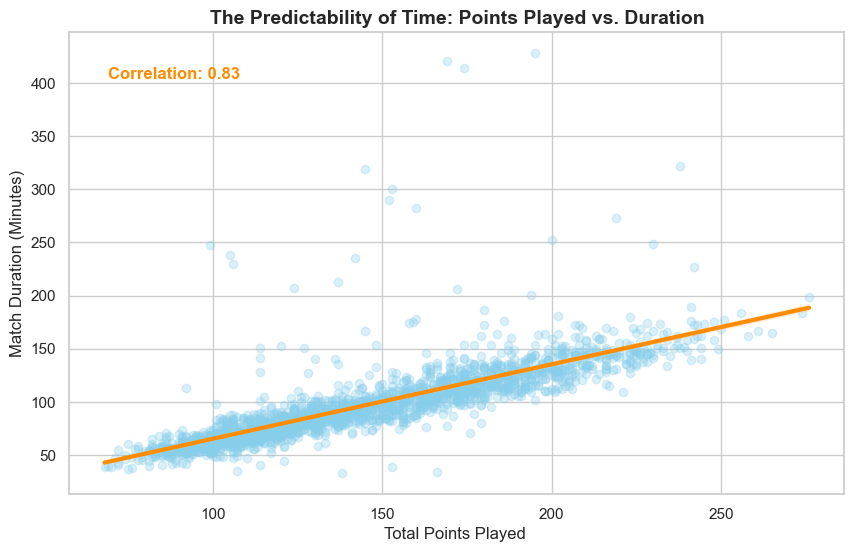

In [11]:
# VISUAL 5: Predicting Match Length (Points vs Duration)
plt.figure(figsize=(10, 6))
# We use a sample of 2000 for a cleaner plot if the data is dense
sns.regplot(data=df_clean.sample(2000), x='total_points', y='wh_minutes', 
            scatter_kws={'alpha': 0.3, 'color': 'skyblue'}, 
            line_kws={'color': 'darkorange', 'lw': 3})

plt.title('The Predictability of Time: Points Played vs. Duration', fontsize=14, fontweight='bold')
plt.xlabel('Total Points Played ', fontsize=12)
plt.ylabel('Match Duration (Minutes)', fontsize=12)

# Calculate correlation to add to your narrative
corr = df_clean['total_points'].corr(df_clean['wh_minutes'])
plt.annotate(f'Correlation: {corr:.2f}', xy=(0.05, 0.9), xycoords='axes fraction', 
             fontsize=12, fontweight='bold', color='darkorange')

plt.savefig('visual5_points_vs_duration.png')

# (Repeat similar logic for visual1_first_set_advantage.png, visual2_duration_dist.png, etc.)

In [12]:
# def serve_points_won_by_match_winner(row):
#     pbp = row['pbp_fixed']
#     match_winner = row['winner']
    
#     total_serve_wins = 0
#     server = 1  # server1 starts
    
#     sets = pbp.split('.')
    
#     for set_data in sets:
#         if not set_data.strip():
#             continue
        
#         games = set_data.split(';')
        
#         for game in games:
#             if not game.strip():
#                 continue
            
#             # If match winner is serving this game
#             if server == match_winner:
#                 total_serve_wins += game.count('S')
            
#             # Switch server after each game
#             server = 2 if server == 1 else 1
    
#     return total_serve_wins


In [13]:
# df_clean['winner_serve_points_won'] = df.apply(
#     serve_points_won_by_match_winner,
#     axis=1
# )
